# 📊 Análise de Dados na Prática
## Mercado de TI com Dados Reais do CAGED
**Semana Acadêmica de Tecnologia da Informação e Comunicação**

---

### O que vamos fazer hoje?

Vamos analisar dados reais do **Novo CAGED** — o Cadastro Geral de Empregados e Desempregados,
mantido pelo Ministério do Trabalho — com foco no setor de Tecnologia da Informação.

Ao final, você será capaz de:
- Carregar e explorar dados reais com **Pandas**
- Limpar e transformar colunas para análise
- Responder perguntas de negócio com código
- Criar visualizações com **Matplotlib** e **Seaborn**
- Construir um dashboard interativo com **Streamlit**

---

> 💬 **Pergunta que vai guiar o minicurso:**  
> *O Acre tem oportunidades reais de emprego em TI? O diploma faz diferença? Mulheres ganham menos?*
> Vamos deixar os dados responderem.

---
# 🧰 Bloco 1 — Preparando o Ambiente

Antes de qualquer análise, precisamos importar as bibliotecas que vamos usar.

| Biblioteca | Para que serve |
|---|---|
| `pandas` | Carregar, filtrar e transformar tabelas de dados |
| `numpy` | Operações numéricas (usada internamente pelo pandas) |
| `matplotlib` | Gerar gráficos |
| `seaborn` | Gráficos estatísticos com visual mais bonito |

> 🟩 **Demonstração:** execute a célula abaixo para importar tudo.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
# 📂 Bloco 2 — Carregando os Dados

## O que é o CAGED?

O **Novo CAGED** registra toda movimentação de emprego formal (CLT) no Brasil: cada admissão
e cada desligamento, com informações sobre salário, escolaridade, gênero, ocupação e localização.

O arquivo que vamos usar é um **recorte já filtrado** com admissões em ocupações de TI.

---

## `pd.read_csv()` — lendo o arquivo

A função `pd.read_csv()` lê um arquivo CSV e transforma em um **DataFrame** —
uma tabela de linhas e colunas que o pandas sabe manipular.

> 🟩 **Demonstração:** carregando o arquivo e conferindo o tamanho.

In [119]:
df = pd.read_csv('caged_ti_br_2022_2024.csv', sep=';', encoding='utf-8')

# shape retorna (linhas, colunas)
print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]}')

Linhas: 1,223,135
Colunas: 14


---
## `.head()` — espiar as primeiras linhas

`df.head(n)` mostra as primeiras **n** linhas do DataFrame (padrão: 5).
É sempre o primeiro passo para entender o que tem na base.

> 🟩 **Demonstração:**

In [3]:
df.head()

,ano,mes,sigla_uf,id_municipio,saldo_movimentacao,tipo_movimentacao,cbo_2002,cnae_2_subclasse,salario_mensal,grau_instrucao,sexo,idade,raca_cor,horas_contratuais
0,2022,1,AC,1200401.0,-1,31,212420,8211300,2970.09,9,1,28.0,1,44.0
1,2022,1,AC,1200401.0,-1,31,317210,8211300,2062.00,8,3,22.0,3,44.0
2,2022,1,AC,1200401.0,-1,40,317210,4682600,1801.43,9,1,33.0,6,51.5
3,2022,1,AC,1200401.0,-1,40,317205,4761003,1212.00,7,1,19.0,6,44.0
4,2022,1,AC,1200401.0,1,97,212410,4321500,1212.00,9,1,19.0,3,44.0


---
## `.info()` — tipos e valores nulos

`df.info()` mostra o **tipo de cada coluna** e quantos valores não-nulos existem.
É onde descobrimos se algo está errado logo de cara.

> 🟩 **Demonstração:**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1223135 entries, 0 to 1223134
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ano                 1223135 non-null  int64  
 1   mes                 1223135 non-null  int64  
 2   sigla_uf            1223135 non-null  str    
 3   id_municipio        1222994 non-null  float64
 4   saldo_movimentacao  1223135 non-null  int64  
 5   tipo_movimentacao   1223135 non-null  int64  
 6   cbo_2002            1223135 non-null  int64  
 7   cnae_2_subclasse    1223135 non-null  int64  
 8   salario_mensal      1223135 non-null  float64
 9   grau_instrucao      1223135 non-null  int64  
 10  sexo                1223135 non-null  int64  
 11  idade               1223091 non-null  float64
 12  raca_cor            1223135 non-null  int64  
 13  horas_contratuais   1223000 non-null  float64
dtypes: float64(4), int64(9), str(1)
memory usage: 130.6 MB


---
## `.describe()` — estatísticas rápidas

`df.describe()` calcula automaticamente contagem, média, desvio padrão, mínimo,
máximo e quartis para todas as colunas numéricas.

> 🟩 **Demonstração:**

In [5]:
df.describe()

,ano,mes,id_municipio,saldo_movimentacao,tipo_movimentacao,cbo_2002,cnae_2_subclasse,salario_mensal,grau_instrucao,sexo,idade,raca_cor,horas_contratuais
count,1.223135e+06,1.223135e+06,1.222994e+06,1.223135e+06,1.223135e+06,1.223135e+06,1.223135e+06,1.223135e+06,1.223135e+06,1.223135e+06,1.223091e+06,1.223135e+06,1.223000e+06
mean,2.022949e+03,6.323926e+00,3.603942e+06,7.259624e-02,6.921339e+01,2.518396e+05,6.261896e+06,5.245868e+03,1.185557e+01,1.428862e+00,3.068708e+01,2.415070e+00,4.145106e+01
std,8.313726e-01,3.372384e+00,7.030144e+05,9.973618e-01,3.035728e+01,5.075685e+04,1.462730e+06,1.979806e+04,1.592681e+01,8.208782e-01,8.905475e+00,1.785779e+00,4.969390e+00
min,2.022000e+03,1.000000e+00,1.100023e+06,-1.000000e+00,1.000000e+01,2.123050e+05,1.113010e+05,1.000000e-02,1.000000e+00,1.000000e+00,1.400000e+01,1.000000e+00,0.000000e+00
25%,2.022000e+03,3.000000e+00,3.304557e+06,-1.000000e+00,4.000000e+01,2.124050e+05,6.201501e+06,2.033000e+03,7.000000e+00,1.000000e+00,2.400000e+01,1.000000e+00,4.000000e+01
50%,2.023000e+03,6.000000e+00,3.550308e+06,1.000000e+00,9.700000e+01,2.124200e+05,6.204000e+06,3.483980e+03,9.000000e+00,1.000000e+00,2.900000e+01,1.000000e+00,4.250000e+01
75%,2.024000e+03,9.000000e+00,4.106902e+06,1.000000e+00,9.700000e+01,3.171100e+05,6.619399e+06,7.000000e+03,9.000000e+00,1.000000e+00,3.600000e+01,3.000000e+00,4.400000e+01
max,2.024000e+03,1.200000e+01,5.300108e+06,1.000000e+00,9.800000e+01,3.172100e+05,9.900800e+06,1.208202e+07,9.900000e+01,9.000000e+00,8.600000e+01,9.000000e+00,9.900000e+01


---
## `.isnull().sum()` — contando valores ausentes

`df.isnull()` marca cada célula como `True` se for nula. `.sum()` soma por coluna.
Resultado: quantos valores faltam em cada campo.

> 🟩 **Demonstração:**

In [120]:
df.isnull().sum().sort_values(ascending=False)

id_municipio          141
horas_contratuais     135
idade                  44
sigla_uf                0
mes                     0
ano                     0
tipo_movimentacao       0
saldo_movimentacao      0
cbo_2002                0
cnae_2_subclasse        0
grau_instrucao          0
salario_mensal          0
sexo                    0
raca_cor                0
dtype: int64

---
> 💬 **Para pensar:** por que alguns campos têm valores nulos? O que pode ter causado isso?

> ✏️ **Desafio:** use `.tail()` para ver as **últimas** 10 linhas do DataFrame.

In [121]:
# ✏️ Digite aqui
df.tail()

,ano,mes,sigla_uf,id_municipio,saldo_movimentacao,tipo_movimentacao,cbo_2002,cnae_2_subclasse,salario_mensal,grau_instrucao,sexo,idade,raca_cor,horas_contratuais
1223130,2024,12,TO,1721000.0,1,97,317210,7739099,1518.0,7,1,25.0,3,44.0
1223131,2024,12,TO,1702109.0,1,97,317205,8610101,1412.0,9,1,28.0,1,44.0
1223132,2024,12,TO,1702109.0,1,97,317210,8610101,1412.0,7,1,27.0,3,44.0
1223133,2024,12,TO,1702109.0,1,97,317210,9511800,1412.0,7,3,19.0,3,44.0
1223134,2024,12,TO,1702109.0,1,97,317210,9511800,1412.0,7,1,18.0,3,44.0


---
# 🧹 Bloco 3 — Limpeza e Preparação dos Dados

Os dados do CAGED usam **códigos numéricos** no lugar de textos.
Por exemplo: `grauinstrucao = 9` significa *Superior Completo*.

Vamos criar colunas com os **rótulos legíveis** para facilitar a análise e os gráficos.

---

## `.map()` — traduzindo códigos para rótulos

`df['coluna'].map(dicionario)` substitui cada valor da coluna pela sua
tradução no dicionário. Valores não encontrados viram `NaN`.

> 🟩 **Demonstração:** mapeando o grau de instrução.

In [122]:
instrucao_map = {
    1: 'Analfabeto',
    2: 'Até 5ª incompleto',
    3: '5ª Completo Fundamental',
    4: '6ª a 9ª Fundamental',
    5: 'Fundamental completo',
    6: 'Médio incompleto',
    7: 'Médio completo',
    8: 'Superior incompleto',
    9: 'Superior completo',
    80: 'Pós-Graduação Completa',
    10: 'Mestrado',
    11: 'Doutorado',
    99: 'Não identificado'
}

df['instrucao_label'] = df['grau_instrucao'].map(instrucao_map)

# Conferindo o resultado
df[['grau_instrucao', 'instrucao_label']].head(8)

,grau_instrucao,instrucao_label
0,9,Superior completo
1,8,Superior incompleto
2,9,Superior completo
3,7,Médio completo
4,9,Superior completo
5,9,Superior completo
6,7,Médio completo
7,8,Superior incompleto


> ✏️ **Desafio:** crie as colunas `sexo_label` e `tipo` usando `.map()`.

> **Dica:**
> - Sexo: `1 → 'Masculino'`, `3 → 'Feminino'`
> - Movimentação: `1 → 'Admissão'`, `2 → 'Desligamento'`

In [123]:
# ✏️ Digite aqui
sexo_map = {
    1: 'Masculino',
    3: 'Feminino',
    9: 'Não identificado'
}

df['sexo_label'] = df['sexo'].map(sexo_map)

df[['sexo', 'sexo_label']].tail()

,sexo,sexo_label
1223130,1,Masculino
1223131,1,Masculino
1223132,1,Masculino
1223133,3,Feminino
1223134,1,Masculino


**Demonstração:** mapeando os cbos de TI usados nesse dataframe.

In [124]:
cbo_map = {
    # Nível superior
    "212305": "Administrador de Banco de Dados",
    "212310": "Administrador de Redes",
    "212315": "Administrador de Sistemas Operacionais",
    "212320": "Engenheiro de Software",
    "212405": "Analista de Desenvolvimento de Sistemas",
    "212410": "Analista de Redes e Comunicação",
    "212415": "Analista de Sistemas de Automação",
    "212420": "Analista de Suporte Computacional",

    # Nível técnico — desenvolvimento
    "317105": "Programador de Internet",
    "317110": "Desenvolvedor de Sistemas",
    "317115": "Programador de Multimídia",
    "317120": "Programador de Sistemas de Informação",
    "317125": "Programador CNC",

    # Nível técnico — suporte
    "317205": "Técnico de Suporte ao Usuário",
    "317210": "Operador de Computador",
    "317215": "Técnico em Manutenção de TI",
}

df['cbo_label'] = df['cbo_2002'].astype(str).map(cbo_map)

---
## Filtrando apenas admissões e removendo salários inválidos

Vamos trabalhar só com **admissões** e remover salários fora de um intervalo razoável
(menos de 30% do salário mínimo ou mais de 150x — provavelmente erros de digitação).

> 🟩 **Demonstração:**

In [125]:
# Filtrar apenas admissões
movimentacao_map = {
    1: 'Admissão',
    -1: 'Desligamento'
}

df['movimentacao_label'] = df['saldo_movimentacao'].map(movimentacao_map)
admissoes = df[df['saldo_movimentacao'] == 1].copy()

print(f'Total de admissões: {len(admissoes):,}')

SM = 1320  # salário mínimo de referência
admissoes = admissoes[
    (admissoes['salario_mensal'] >= SM * 0.3) &
    (admissoes['salario_mensal'] <= SM * 150)
]

print(f'Total de admissões válidas: {len(admissoes):,}')
df[['saldo_movimentacao', 'movimentacao_label']].head()

Total de admissões: 655,965
Total de admissões válidas: 655,193


,saldo_movimentacao,movimentacao_label
0,-1,Desligamento
1,-1,Desligamento
2,-1,Desligamento
3,-1,Desligamento
4,1,Admissão


> ✏️ **Desafio:** quantas admissões são do Acre (código UF = 12)?

> **Dica:** filtre `admissoes[admissoes['uf'] == 12]` e use `len()`.

In [126]:
# ✏️ Digite aqui
admissoes_ac = admissoes[admissoes['sigla_uf'] == 'AC']

print(f'Total de admissões do Acre: {len(admissoes_ac):,}')

Total de admissões do Acre: 457


---
# 🔍 Bloco 4 — Análise Exploratória

Agora começa a parte mais importante: **fazer perguntas e respondê-las com código**.

A cada resultado, a pergunta mais importante não é *'o que o código retornou?'*,
mas sim: *'o que isso significa? o que pode estar distorcendo esse número?'*

---

## Análise 1 — O diploma faz diferença em TI?

**Pergunta:** profissionais com ensino superior ganham significativamente mais
do que técnicos e quem tem só o médio completo?

### `.groupby()` + `.agg()` — agrupando e calculando

`groupby('coluna')` divide o DataFrame em grupos. 

`.agg()` aplica funções (média, mediana, contagem) em cada grupo.

Usamos **mediana** em vez de média porque salários têm outliers altos que distorcem.

> 🟩 **Demonstração:**

In [127]:
admissoes['grau_instrucao'].value_counts()

grau_instrucao
9     276611
7     175241
8     148103
80     32949
6      10139
10      5785
5       2302
11      2249
4       1078
1        465
3        140
2        131
Name: count, dtype: int64

In [128]:
ordem_instrucao = [
    'Analfabeto', 'Até 5ª incompleto', '5ª Completo Fundamental', '6ª a 9ª Fundamental', 
    'Fundamental completo', 'Médio incompleto', 'Médio completo', 'Superior incompleto', 
    'Superior completo', 'Pós-Graduação Completa', 'Mestrado', 'Doutorado', 'Não identificado'
]

admissoes['instrucao_label'] = admissoes['instrucao_label'].astype(
    pd.CategoricalDtype(categories=ordem_instrucao, ordered=True)
)

cbo_instrucao = (
    admissoes
    .groupby(['instrucao_label', 'cbo_label'])
    .size()
    .reset_index(name='admissoes')
    .sort_values(['instrucao_label', 'admissoes'], ascending=[False, False])
    .groupby('instrucao_label')
    .head(3)
)

cbo_instrucao

,instrucao_label,cbo_label,admissoes
153,Doutorado,Analista de Desenvolvimento de Sistemas,1242
156,Doutorado,Analista de Suporte Computacional,282
157,Doutorado,Desenvolvedor de Sistemas,157
139,Mestrado,Analista de Desenvolvimento de Sistemas,3448
143,Mestrado,Desenvolvedor de Sistemas,717
142,Mestrado,Analista de Suporte Computacional,455
125,Pós-Graduação Completa,Analista de Desenvolvimento de Sistemas,17954
128,Pós-Graduação Completa,Analista de Suporte Computacional,3838
129,Pós-Graduação Completa,Desenvolvedor de Sistemas,3411
111,Superior completo,Analista de Desenvolvimento de Sistemas,125133


In [129]:
gap_salarial = (
    admissoes
    .groupby(['instrucao_label', 'cbo_label', 'sexo_label'])['salario_mensal']
    .median()
    .unstack('sexo_label')
    .reset_index()
    .dropna()
)

# Calculando a diferença percentual
gap_salarial['diferenca_%'] = (
    (gap_salarial['Masculino'] - gap_salarial['Feminino']) / gap_salarial['Feminino'] * 100
).round(1)

gap_salarial.sort_values(['instrucao_label', 'diferenca_%'], ascending=False)

sexo_label,instrucao_label,cbo_label,Feminino,Masculino,diferenca_%
163,Doutorado,Técnico de Suporte ao Usuário,2500.000,9000.000,260.0
162,Doutorado,Programador de Sistemas de Informação,2508.945,8410.015,235.2
152,Doutorado,Administrador de Sistemas Operacionais,6000.000,9940.675,65.7
157,Doutorado,Desenvolvedor de Sistemas,6004.815,8000.000,33.2
153,Doutorado,Analista de Desenvolvimento de Sistemas,8000.000,10000.000,25.0
...,...,...,...,...,...
6,Analfabeto,Analista de Suporte Computacional,2261.675,2550.000,12.7
9,Analfabeto,Operador de Computador,1800.000,1846.685,2.6
12,Analfabeto,Técnico de Suporte ao Usuário,1435.650,1440.000,0.3
2,Analfabeto,Administrador de Sistemas Operacionais,8000.000,3500.500,-56.2


In [130]:
top_combos = cbo_instrucao[['instrucao_label', 'cbo_label']]

gap_top = top_combos.merge(gap_salarial, on=['instrucao_label', 'cbo_label'], how='left')

gap_top.sort_values(['instrucao_label', 'diferenca_%'], ascending=[False, False])

,instrucao_label,cbo_label,Feminino,Masculino,diferenca_%
2,Doutorado,Desenvolvedor de Sistemas,6004.815,8000.000,33.2
0,Doutorado,Analista de Desenvolvimento de Sistemas,8000.000,10000.000,25.0
1,Doutorado,Analista de Suporte Computacional,3800.000,2848.530,-25.0
4,Mestrado,Desenvolvedor de Sistemas,5557.200,8500.000,53.0
3,Mestrado,Analista de Desenvolvimento de Sistemas,8231.150,10000.000,21.5
5,Mestrado,Analista de Suporte Computacional,6901.665,7352.380,6.5
8,Pós-Graduação Completa,Desenvolvedor de Sistemas,6675.630,8965.400,34.3
7,Pós-Graduação Completa,Analista de Suporte Computacional,4474.500,5504.860,23.0
6,Pós-Graduação Completa,Analista de Desenvolvimento de Sistemas,8064.520,9800.000,21.5
11,Superior completo,Desenvolvedor de Sistemas,4590.000,6200.000,35.1


> 💬 **Para pensar:**
> - A diferença entre médio completo e superior completo é grande ou pequena?
> - Mestrado e doutorado aparecem bem no ranking? O que isso diz sobre o mercado de TI?
> - Esse número por si só justifica fazer uma graduação? O que mais pesa nessa decisão?

> ✏️ **Desafio:** calcule a **média** (não mediana) salarial por grau de instrução
> e compare com os resultados acima. A ordem mudou? Por que a mediana pode ser mais honesta aqui?

In [131]:
# ✏️ Digite aqui
salario_instrucao = (
    admissoes
    .groupby('instrucao_label')['salario_mensal']
    .agg(salario_media='mean', admissoes='count')
    .sort_values('salario_media', ascending=False)
)

salario_instrucao

,salario_media,admissoes
instrucao_label,,
Mestrado,9884.368119,5785
Doutorado,8965.759062,2249
Pós-Graduação Completa,8937.894935,32949
Superior completo,6605.099366,276611
Superior incompleto,3841.800144,148103
Analfabeto,3822.644580,465
Até 5ª incompleto,3033.327099,131
5ª Completo Fundamental,2847.540215,140
Médio completo,2750.855014,175241


---
## Análise 2 — Gap de gênero: mulheres em TI ganham menos?

**Pergunta:** dado o mesmo nível de escolaridade, há diferença salarial
entre homens e mulheres nas admissões em TI?

### `.unstack()` — pivotando o resultado do groupby

`groupby` com dois campos gera um índice multinível.
`.unstack('coluna')` transforma um dos níveis em colunas — fica mais fácil comparar.

> 🟩 **Demonstração:**

In [132]:
gap = (
    admissoes
    .groupby(['instrucao_label', 'sexo_label'])['salario_mensal']
    .median()
    .unstack('sexo_label')
    .dropna()
)

gap['Diferença (%)'] = (
    (gap['Masculino'] - gap['Feminino']) / gap['Feminino'] * 100
).round(1)

gap.sort_values('Diferença (%)', ascending=False)

sexo_label,Feminino,Masculino,Diferença (%)
instrucao_label,,,
Médio incompleto,898.93,1468.48,63.4
5ª Completo Fundamental,1413.38,2033.60,43.9
Superior completo,4500.00,5897.00,31.0
Até 5ª incompleto,1550.00,2000.00,29.0
Pós-Graduação Completa,7075.85,8899.00,25.8
Analfabeto,2030.20,2500.00,23.1
Mestrado,7753.00,9470.20,22.1
Doutorado,7010.00,8500.00,21.3
Fundamental completo,1550.00,1846.04,19.1


> 💬 **Para pensar:**
> - Em qual nível de escolaridade o gap é maior?
> - O CAGED consegue **explicar** essa diferença ou só **mostrá-la**?
> - O que mais precisaríamos saber para afirmar que há discriminação salarial?

> ✏️ **Desafio:** calcule quantas admissões femininas e masculinas existem na base.
> Use `admissoes['sexo_label'].value_counts()`. O desequilíbrio de representação
> pode afetar a análise salarial? Como?

In [133]:
# ✏️ Digite aqui
admissoes['sexo_label'].value_counts()

sexo_label
Masculino    512795
Feminino     142398
Name: count, dtype: int64

---
## Análise 3 — Onde estão os empregos de TI? Acre vs. Brasil

**Pergunta:** o Acre aparece entre os estados com mais oportunidades em TI?
O salário praticado aqui se aproxima da média nacional?

### `.value_counts()` — contando ocorrências

`value_counts()` conta quantas vezes cada valor único aparece em uma coluna
e já retorna ordenado do mais frequente para o menos.

> 🟩 **Demonstração:**

In [134]:
admissoes['uf_label'] = admissoes['sigla_uf']

# Top 10 estados por admissões em TI
admissoes['uf_label'].value_counts().head(10)

uf_label
SP    301774
MG     57420
SC     45728
RJ     41733
PR     41338
RS     41126
DF     25543
CE     14478
BA     12410
GO     11587
Name: count, dtype: int64

In [135]:
# Acre vs. média nacional
sal_ac = admissoes[admissoes['uf_label'] == 'AC']['salario_mensal'].median()
sal_br = admissoes['salario_mensal'].median()

print(f'Acre:   R$ {sal_ac:,.0f}')
print(f'Brasil: R$ {sal_br:,.0f}')
print(f'AC representa {sal_ac/sal_br*100:.1f}% da mediana nacional')

Acre:   R$ 1,600
Brasil: R$ 3,264
AC representa 49.0% da mediana nacional


> 💬 **Para pensar:**
> - Faz sentido comparar salários do Acre com SP sem ajustar pelo custo de vida?
> - Migrar para outro estado compensa financeiramente para quem trabalha com TI?

> ✏️ **Desafio:** calcule a mediana salarial para **todos os estados** e ordene
> do maior para o menor. O Acre fica em qual posição no ranking nacional?

In [136]:
# ✏️ Digite aqui
mediana_salarial_uf = (
    admissoes
    .groupby('uf_label')['salario_mensal']
    .agg(mediana_salarial='median', admissoes='count')
    .sort_values('mediana_salarial', ascending=False)
)

mediana_salarial_uf

,mediana_salarial,admissoes
uf_label,,
DF,5278.52000,25543
SP,4282.20000,301774
RJ,3548.65000,41733
AM,3000.00000,4919
RS,3000.00000,41126
MG,2824.00000,57420
PR,2794.00000,41338
PE,2525.09005,10664
UF não identificada,2500.00000,87


---
## Análise 4 — O mercado de TI está crescendo?

**Pergunta:** nos últimos meses, o saldo de empregos formais em TI
foi positivo (mais admissões que desligamentos) ou negativo?

### `pd.to_datetime()` e agrupamento temporal

O campo `competencia` está no formato `YYYYMM` (ex: `202401`).
Vamos convertê-lo para data e agrupar por mês para ver a evolução.

> 🟩 **Demonstração:**

In [137]:
saldo = (
    df.groupby(['ano', 'mes', 'saldo_movimentacao'])
    .size()
    .unstack('saldo_movimentacao')
    .fillna(0)
    .rename(columns={1: 'Admissão', -1: 'Desligamento'})
)

saldo['Saldo'] = saldo['Admissão'] - saldo['Desligamento']

saldo[['Admissão', 'Desligamento', 'Saldo']]

saldo_movimentacao  Admissão  Desligamento  Saldo
ano  mes                                         
2022 1                 22913         16493   6420
     2                 22177         17604   4573
     3                 23598         18153   5445
     4                 22458         18450   4008
     5                 22643         18032   4611
     6                 22403         17941   4462
     7                 21579         17673   3906
     8                 22280         17947   4333
     9                 21503         16890   4613
     10                19230         15448   3782
     11                17475         15132   2343
     12                13379         13814   -435
2023 1                 18833         15887   2946
     2                 14869         14967    -98
     3                 17305         16737    568
     4                 16641         14988   1653
     5                 17196         15579   1617
     6                 16645         15645   1000
     7                 16427         14685   1742
     8                 17568         15750   1818
     9                 15832         14279   1553
     10                16505         14471   2034
     11                15095         12805   2290
     12                12672         13216   -544
2024 1                 17817         14462   3355
     2                 15827         14944    883
     3                 17192         15278   1914
     4                 18623         15828   2795
     5                 17383         16160   1223
     6                 16910         15055   1855
     7                 18295         15629   2666
     8                 19110         16577   2533
     9                 18830         15801   3029
     10                18910         16457   2453
     11                16444         14688   1756
     12                13398         13705   -307

> 💬 **Para pensar:**
> - Há meses com saldo negativo? O que pode explicar isso?
> - Existe algum padrão sazonal (mesmos meses com queda todo ano)?

> ✏️ **Desafio:** calcule o saldo **acumulado** do período com `.cumsum()`
> na coluna `Saldo`. O mercado de TI cresceu ou encolheu no total?

In [138]:
# ✏️ Digite aqui
saldo['Saldo_Acumulado'] = saldo['Saldo'].cumsum()

saldo[['Admissão', 'Desligamento', 'Saldo', 'Saldo_Acumulado']]

saldo_movimentacao  Admissão  Desligamento  Saldo  Saldo_Acumulado
ano  mes                                                          
2022 1                 22913         16493   6420             6420
     2                 22177         17604   4573            10993
     3                 23598         18153   5445            16438
     4                 22458         18450   4008            20446
     5                 22643         18032   4611            25057
     6                 22403         17941   4462            29519
     7                 21579         17673   3906            33425
     8                 22280         17947   4333            37758
     9                 21503         16890   4613            42371
     10                19230         15448   3782            46153
     11                17475         15132   2343            48496
     12                13379         13814   -435            48061
2023 1                 18833         15887   2946            51007
     2                 14869         14967    -98            50909
     3                 17305         16737    568            51477
     4                 16641         14988   1653            53130
     5                 17196         15579   1617            54747
     6                 16645         15645   1000            55747
     7                 16427         14685   1742            57489
     8                 17568         15750   1818            59307
     9                 15832         14279   1553            60860
     10                16505         14471   2034            62894
     11                15095         12805   2290            65184
     12                12672         13216   -544            64640
2024 1                 17817         14462   3355            67995
     2                 15827         14944    883            68878
     3                 17192         15278   1914            70792
     4                 18623         15828   2795            73587
     5                 17383         16160   1223            74810
     6                 16910         15055   1855            76665
     7                 18295         15629   2666            79331
     8                 19110         16577   2533            81864
     9                 18830         15801   3029            84893
     10                18910         16457   2453            87346
     11                16444         14688   1756            89102
     12                13398         13705   -307            88795

In [139]:
saldo_anual = (
    saldo
    .groupby('ano')[['Admissão', 'Desligamento', 'Saldo']]
    .sum()
)

saldo_anual['Saldo_Acumulado'] = saldo_anual['Saldo'].cumsum()

saldo_anual

saldo_movimentacao,Admissão,Desligamento,Saldo,Saldo_Acumulado
ano,,,,
2022,251638,203577,48061,48061
2023,195588,179009,16579,64640
2024,208739,184584,24155,88795


---
# 📊 Bloco 5 — Visualização e Storytelling com Dados

Dados viram argumento quando acompanhados de um gráfico claro.
Mas gráficos também podem enganar — escala errada, cor que induz, eixo truncado.

> **Regra de ouro:** se precisar de três parágrafos para explicar um gráfico, o gráfico está errado.

---

## Gráfico 1 — Salário mediano por escolaridade (barplot horizontal)

**Quando usar:** comparar uma métrica entre categorias, especialmente quando os rótulos são longos.
O barplot horizontal facilita a leitura dos nomes.

> 🟩 **Demonstração:**

C:\Users\sonda.lunahsc\AppData\Local\Temp\ipykernel_20756\239327093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


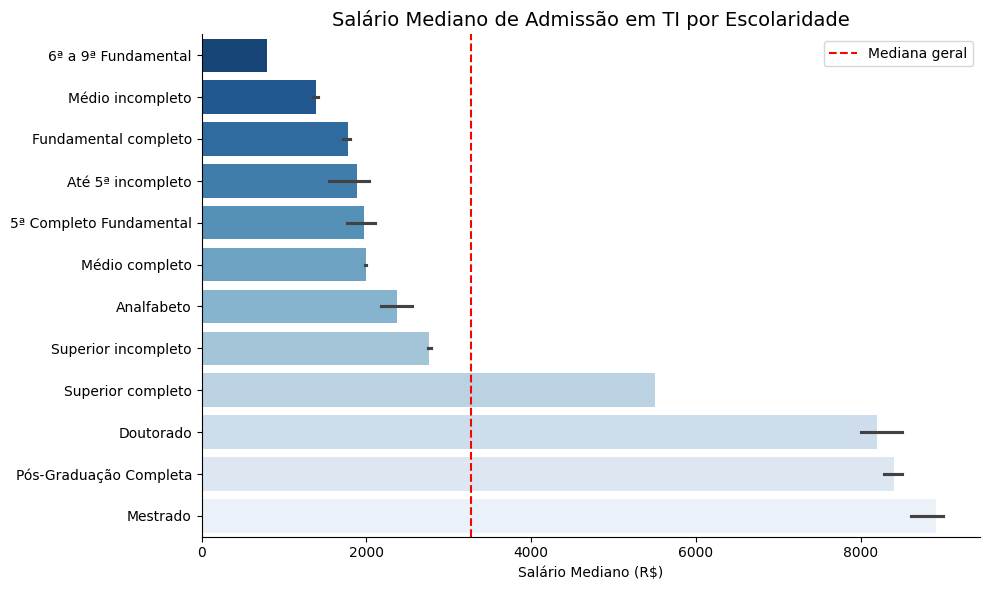

In [140]:
ordem = (
    admissoes.groupby('instrucao_label')['salario_mensal']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=admissoes,
    y='instrucao_label', x='salario_mensal',
    order=ordem,
    estimator='median',
    palette='Blues_r',
    ax=ax
)

ax.axvline(admissoes['salario_mensal'].median(), color='red',
           linestyle='--', label='Mediana geral')
ax.set_title('Salário Mediano de Admissão em TI por Escolaridade', fontsize=14)
ax.set_xlabel('Salário Mediano (R$)')
ax.set_ylabel('')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

> ✏️ **Desafio:** mude a cor do gráfico trocando `palette='Blues_r'` por outra
> (ex: `'Greens_r'`, `'Oranges_r'`, `'viridis'`). Explore e veja como a escolha
> de cor afeta a percepção visual.

In [ ]:
# ✏️ Digite aqui


---
## Gráfico 2 — Distribuição salarial por gênero (boxplot)

**Quando usar:** mostrar não só a média/mediana, mas **como os dados estão distribuídos**.
O boxplot revela mediana, quartis e outliers ao mesmo tempo.

**Como ler:** a linha do meio é a mediana. A caixa cobre 50% dos dados (Q1 a Q3).
Os pontos além dos 'bigodes' são outliers.

> 🟩 **Demonstração:**

C:\Users\sonda.lunahsc\AppData\Local\Temp\ipykernel_20756\925114862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


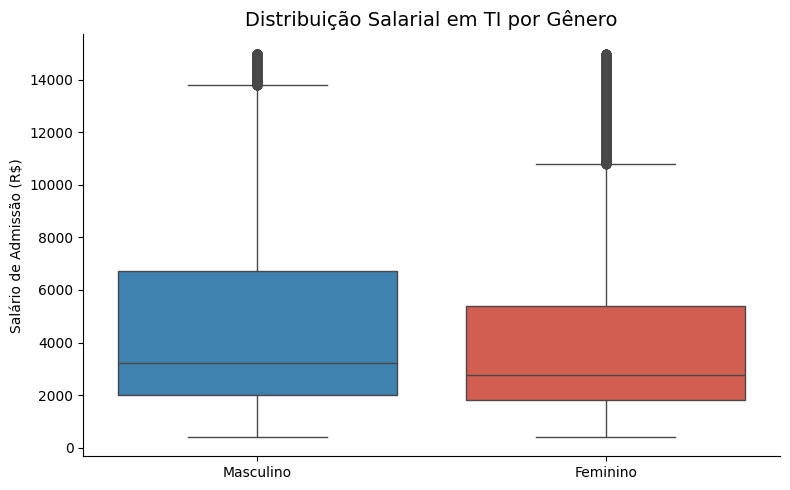

In [142]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=admissoes[admissoes['salario_mensal'] < 15000],
    x='sexo_label', y='salario_mensal',
    palette={'Masculino': '#2E86C1', 'Feminino': '#E74C3C'},
    ax=ax
)

ax.set_title('Distribuição Salarial em TI por Gênero', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Salário de Admissão (R$)')
sns.despine()
plt.tight_layout()
plt.show()

> ✏️ **Desafio:** adicione `hue='instrucao_label'` ao boxplot para ver
> a distribuição salarial separada por gênero **e** escolaridade ao mesmo tempo.
> O gráfico ficou mais claro ou mais confuso? O que isso nos ensina sobre visualização?

In [ ]:
# ✏️ Digite aqui


---
## Gráfico 3 — Saldo mensal de empregos em TI (série temporal)

**Quando usar:** mostrar **evolução ao longo do tempo**. Linhas comunicam
tendência melhor do que barras quando o eixo X é temporal e contínuo.

> 🟩 **Demonstração:**

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

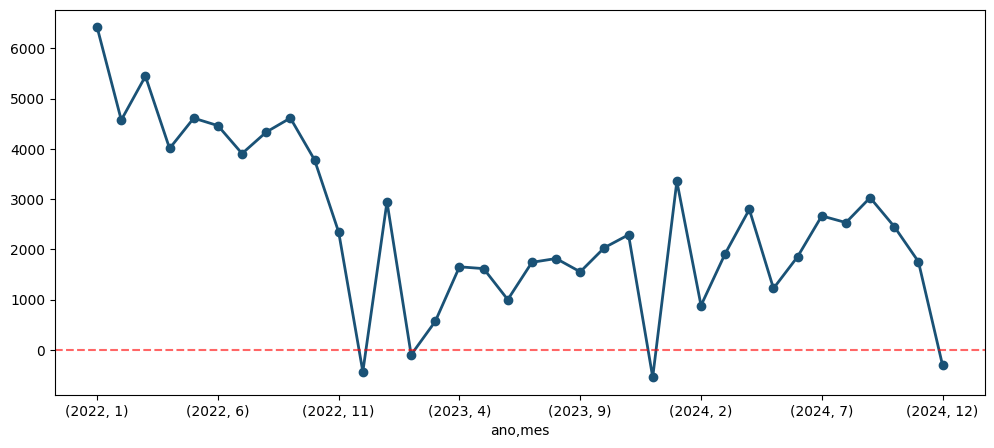

In [143]:
fig, ax = plt.subplots(figsize=(12, 5))

saldo['Saldo'].plot(ax=ax, marker='o', linewidth=2, color='#1A5276')

ax.axhline(0, color='red', linestyle='--', alpha=0.6)
ax.fill_between(saldo.index, saldo['Saldo'], 0,
    where=saldo['Saldo'] >= 0, alpha=0.2, color='green', label='Saldo positivo')
ax.fill_between(saldo.index, saldo['Saldo'], 0,
    where=saldo['Saldo'] < 0, alpha=0.2, color='red', label='Saldo negativo')

ax.set_title('Saldo Mensal de Empregos Formais em TI (2022–2024)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Admissões – Desligamentos')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

> ✏️ **Desafio:** filtre o `saldo` apenas para os últimos 6 meses e refaça o gráfico.
> O comportamento recente é diferente da tendência geral?

> **Dica:** `saldo.tail(6)['Saldo'].plot(...)`

In [ ]:
# ✏️ Digite aqui


---
# 🚀 Bloco 6 — Dashboard com Streamlit

Tudo que fizemos até aqui ficou dentro do notebook — só quem tem Jupyter consegue rodar.
O **Streamlit** transforma sua análise em um app web que qualquer pessoa pode acessar
pelo navegador, sem instalar nada.

---

## Como funciona

- Você escreve um arquivo `.py` normal
- Roda com `streamlit run app.py` no terminal
- O Streamlit abre um servidor local e re-executa o script **toda vez** que um filtro muda
- Deploy gratuito em [streamlit.io/cloud](https://streamlit.io/cloud)

---

## Componentes principais

| Componente | O que faz |
|---|---|
| `st.title()` | Título da página |
| `st.metric()` | Caixa de número com rótulo |
| `st.sidebar` | Painel lateral de filtros |
| `st.selectbox()` | Menu dropdown |
| `st.multiselect()` | Seleção múltipla |
| `st.slider()` | Controle deslizante |
| `st.pyplot()` | Exibe um gráfico matplotlib |
| `st.dataframe()` | Exibe uma tabela interativa |
| `@st.cache_data` | Evita recarregar dados a cada interação |

> 🟩 **Demonstração:** o código abaixo é o app completo. Cole em um arquivo `app.py`
> e rode `streamlit run app.py` no terminal.

In [ ]:
# ── Cole este conteúdo em um arquivo chamado app.py ──────────────────────
# ── e rode no terminal: streamlit run app.py ─────────────────────────────

app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title='Mercado de TI — CAGED', page_icon='💻', layout='wide')

@st.cache_data
def carregar_dados():
    df = pd.read_csv('caged_ti_ac_2022_2024.csv', sep=';')
    instrucao_map = {
        1:'Analfabeto', 2:'Até 5ª incompleto', 3:'Até 5ª completo',
        4:'6ª-9ª incompleto', 5:'Fund. completo', 6:'Médio incompleto',
        7:'Médio completo', 8:'Superior incompleto',
        9:'Superior completo', 10:'Mestrado', 11:'Doutorado'
    }
    df['instrucao_label'] = df['grauinstrucao'].map(instrucao_map)
    df['sexo_label'] = df['sexo'].map({1:'Masculino', 3:'Feminino'})
    df['tipo'] = df['movimentacao'].map({1:'Admissão', 2:'Desligamento'})
    return df[df['tipo'] == 'Admissão']

df = carregar_dados()

st.title('💻 Mercado de TI Formal no Brasil')
st.markdown('Dados do **Novo CAGED** — Ministério do Trabalho e Emprego')
st.divider()

# Filtros na sidebar
st.sidebar.header('🎛️ Filtros')
sexo_sel = st.sidebar.multiselect('Gênero:', ['Masculino', 'Feminino'],
                                   default=['Masculino', 'Feminino'])
faixa = st.sidebar.slider('Faixa salarial (R$):', 0, 30000, (0, 15000))

filtrado = df[
    df['sexo_label'].isin(sexo_sel) &
    df['salario'].between(faixa[0], faixa[1])
]

# Métricas
c1, c2, c3 = st.columns(3)
c1.metric('Total de Admissões', f'{len(filtrado):,}')
c2.metric('Salário Mediano', f"R$ {filtrado['salario'].median():,.0f}")
c3.metric('Salário Médio', f"R$ {filtrado['salario'].mean():,.0f}")
st.divider()

# Gráficos
col1, col2 = st.columns(2)

with col1:
    st.subheader('Salário Mediano por Escolaridade')
    ordem = filtrado.groupby('instrucao_label')['salario'].median().sort_values().index
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(data=filtrado, y='instrucao_label', x='salario',
                order=ordem, estimator='median', palette='Blues_r', ax=ax)
    ax.set_xlabel('R$'); ax.set_ylabel('')
    sns.despine(); st.pyplot(fig); plt.close()

with col2:
    st.subheader('Distribuição Salarial por Gênero')
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=filtrado, x='sexo_label', y='salario',
                palette={'Masculino':'#2E86C1','Feminino':'#E74C3C'}, ax=ax)
    ax.set_xlabel(''); ax.set_ylabel('Salário (R$)')
    sns.despine(); st.pyplot(fig); plt.close()

with st.expander('📋 Ver dados brutos'):
    st.dataframe(filtrado.head(500))
'''

print(app_code)

> ✏️ **Desafio:** adicione um novo filtro de escolaridade na sidebar do app.

> **Dica:**
> ```python
> niveis = sorted(df['instrucao_label'].dropna().unique())
> nivel_sel = st.sidebar.multiselect('Escolaridade:', niveis, default=niveis)
> # ... e inclua no filtro: & df['instrucao_label'].isin(nivel_sel)
> ```

In [ ]:
# ✏️ Digite aqui


---
# 🏁 Encerramento

## O que os dados nos disseram?

- ✅ Escolaridade **impacta** o salário em TI — mas o quanto?
- ✅ Existe gap salarial de gênero — mas o CAGED não consegue **explicar** por quê
- ✅ Os empregos de TI estão **concentrados geograficamente** — e o Acre fica onde?
- ✅ O mercado formal de TI tem tendência de crescimento — com exceções

## O que os dados **não** nos disseram?

- ❌ PJ, MEI e freelancers **não estão no CAGED** — e em TI essa fatia é enorme
- ❌ Salário de admissão ≠ salário atual
- ❌ CBO de TI é impreciso — muitos profissionais são registrados em CBOs genéricos
- ❌ Correlação não é causalidade: diploma alto + salário alto pode ter terceiras variáveis

---

## Para continuar

| Recurso | Link |
|---|---|
| Novo CAGED (dados completos) | pdet.mte.gov.br |
| Base dos Dados (BigQuery + Python) | basedosdados.org |
| Documentação Pandas | pandas.pydata.org |
| Documentação Streamlit | docs.streamlit.io |
| Kaggle Learn (gratuito) | kaggle.com/learn |

---

> 💬 **Pergunta final:** com tudo que você viu hoje,
> **qual análise você faria se tivesse os dados completos e mais tempo?**